# Homework 4: Does international student exchange increase the number of multi-national research publications?

### **Research Question and Study Overview**
- International student exchange and foreign study can be a valuable experience on an individual level. But does it have larger effects on high-level research collaboration?
- This study hypothesizes that countries with higher levels of international student exchange (in terms of inbound or outbound students) will have a more collaborative research record.
- Authorship data from the prestigious journals Nature (all scientific fields) and Cell (focused on cell biology) was obtained for publications between 2000-2026. This data was processed and analyzed to ultimately identify how many different countries participated on each publication.
- Data on inbound and outbound international student exchange was obtained from Unesco (indicator codes: 'OE.5T8.40510' and '26637'). This data is separated by country, and contains data from roughly 2000-2025 (although there are many gaps).

### **Project Summary**
- **Project Title:** Does international student exchange foster cross-country research collaborations?
- **Student Name:** Joe Carver
- **Policy Relevance Statement:** Many countries (such as Japan) dedicate significant resources to supporting student exchange. While this is expected to have many benefits, a connection to research output and collaboration could be further evidence of its positive effect.
- **Central Hypothesis:** Countries with more student exchange have more collaborative research output (in terms of publications with authors from multiple countries)

## 1. Download Data

### **Data Acquisition Details**
- **Primary Data Source:** Pubmed author and publication data from Nature and Cell journals, 2000-2026. Retrieved using Entrez API and Biopython package.
- **Secondary Data Source:** Unesco data on international student exchange. Retrieved using Unesco API and requests.
- ***Variables Retrieved:*** OE.5T8.40510: total outbound tertiary students and 26637: total inbound tertiary students
- **Local Storage Path:** `final_project_joe_carver/data/raw/`

In [ ]:
import sys
from pathlib import Path

# Add the example basic project folder to sys.path
src_dir = Path("../src/").resolve()
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))


# ---------------------------------
# fetch Pubmed data
# ---------------------------------

import fetch_pubmed
fetch_pubmed.run()

done fetching Nature pubmed data
no errors occurred. 366969 authors retrieved from 35064 publications
done fetching Cell pubmed data
no errors occurred. 122208 authors retrieved from 11209 publications


In [ ]:
# ---------------------------------
# fetch Unesco data
# ---------------------------------
import fetch_unesco
fetch_unesco.run()

data saved to : /Users/jocarver/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/final_project_joe_carver/data/raw/total_outbound_tertiary_students_2000-2026.csv
data saved to : /Users/jocarver/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/final_project_joe_carver/data/raw/total_inbound_tertiary_students_2000-2026.csv


## 2. Manipulate Data

### **Preprocessing Summary**
- **Unesco Data Cleaning Strategy:** 
- Unesco data was transformed to long and missing data values were linearly interpolated in a forward manner (i.e. if data was missing in 2000, present in 2001, and missing in 2002, interpolation added data to 2002 but not backwards to 2000). Country name was also added from three letter country codes present in the raw data.
    - **Pre-cleaned Observations:** (note these numbers may change if code is re-run)
    - inbound students: 6993 rows, 6 columns
    - outbound students: 10276 rows, 6 columns
    - **Final Dataset Observations:** 
    - inbound students: 10271 rows, 4 columns
    - outbound students: 10345 rows, 4 columns
    - **Clean Data Path:** 
    - /final_project_joe_carver/data/processed/inbound_students_processed.csv
    - /final_project_joe_carver/data/processed/outbound_students_processed.csv
    
- **Pubmed Data Cleaning Strategy:** 
- Pubmed author data was processed with regex to find the string likely to be the affiliation country in each author record. Many authors have multiple affiliations; the first affiliation was taken to the be primary affiliation and country was pulled from it. Since the formatting of affiliations is not standardized, there are many instances where a non-country (i.e. ~~ Institute) or an alternative name for a country (i.e. PRC or China) was present. Some attempt was made to deal with common instances, but not all values were checked manually.
    - **Pre-cleaned Observations:** (note these numbers may change if code is re-run)
    - Cell authors: 122209 rows, 4 columns
    - Nature authors: 366970 rows, 4 columns
    - **Final Dataset Observations:** 
    - Cell authors: 122197 rows, 6 columns (some NA dropped, added primary affiliation and primary country columns)
    - Nature authors: 365904 rows, 6 columns (some NA dropped, added primary affiliation and primary country columns)
    - **Clean Data Path:** `
    - /final_project_joe_carver/data/processed/cell_processed_author_data.csv
    - /final_project_joe_carver/data/processed/nature_processed_author_data.csv




In [ ]:
# ---------------------------------
# clean Pubmed data
# ---------------------------------
import clean_pubmed
clean_pubmed.run()

finished processing Cell and Nature data, output to /Users/jocarver/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/final_project_joe_carver/data/processed


In [4]:
# ---------------------------------
# clean Unesco data
# ---------------------------------
import clean_unesco
clean_unesco.run()

finished cleaning Unesco data, saved to: /Users/jocarver/Documents/GitHub/datascience-publicpolicy-2026/notebooks/hw/final_project_joe_carver/data/processed


## 3. Exploratory visualizations

### **Visualizations & Observations**
- **Pubmed Author Data Key Takeaway:** Average number of authors and countries per publication increases over time -> growing complexity of science and necessity of collaboration?
- **Unesco International Student Data Key Takeaway:** USA, the UK, and Australia rank top for total inbound international tertiary students, while China, India, and Vietnam have the highest total numbers of outbound students

- other takeaways underneath individual figures



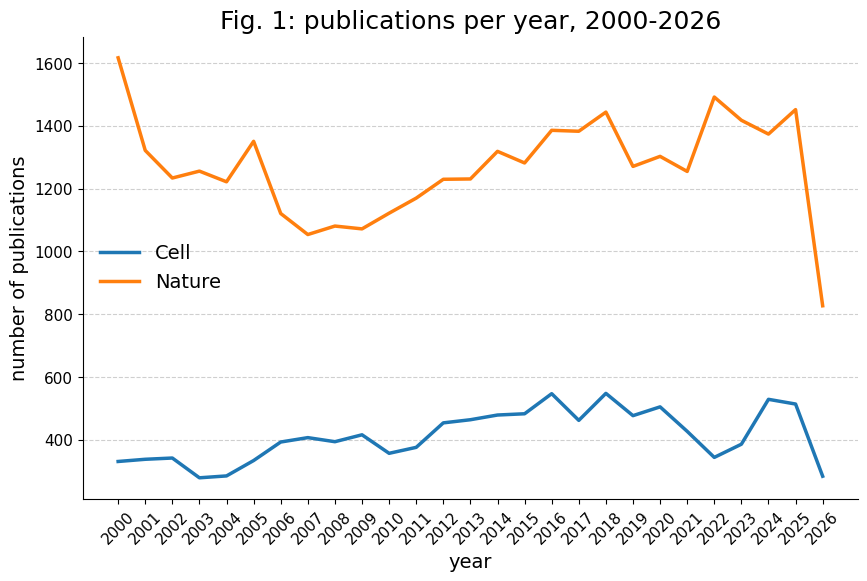


        ### Figure 1 takeaways: publication number holds steady over time for each journal.
        

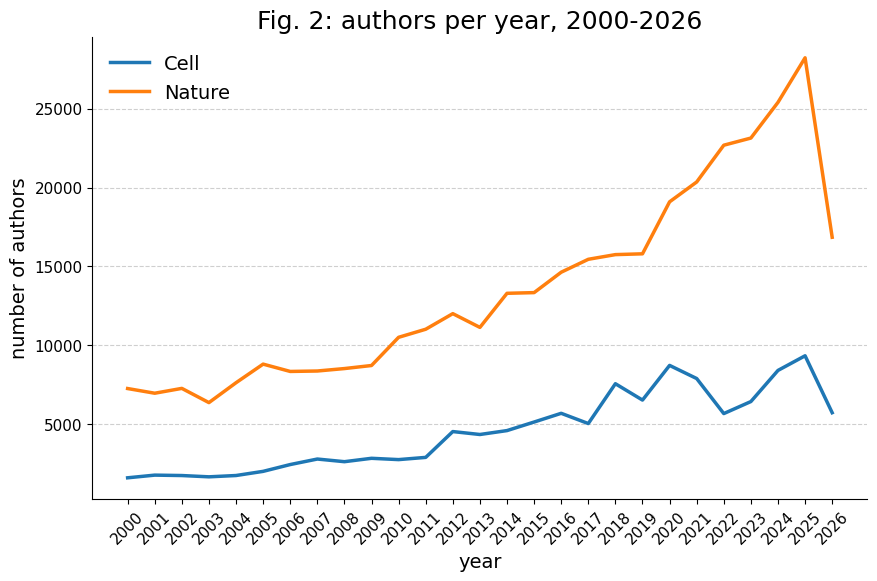


        ### Figure 2 takeaways: total number of authors increase over time.
        

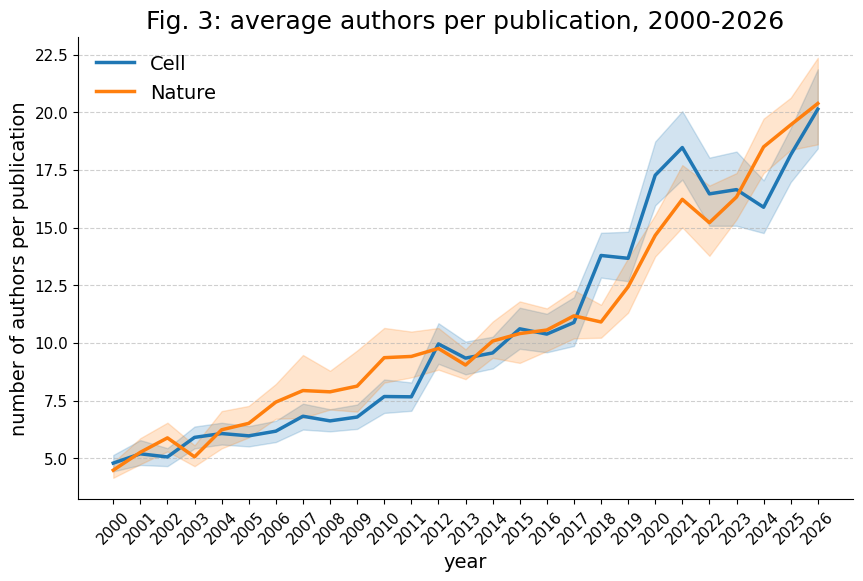


        ### Figure 3 takeaways: average number of authors per publication also increases over time.
        

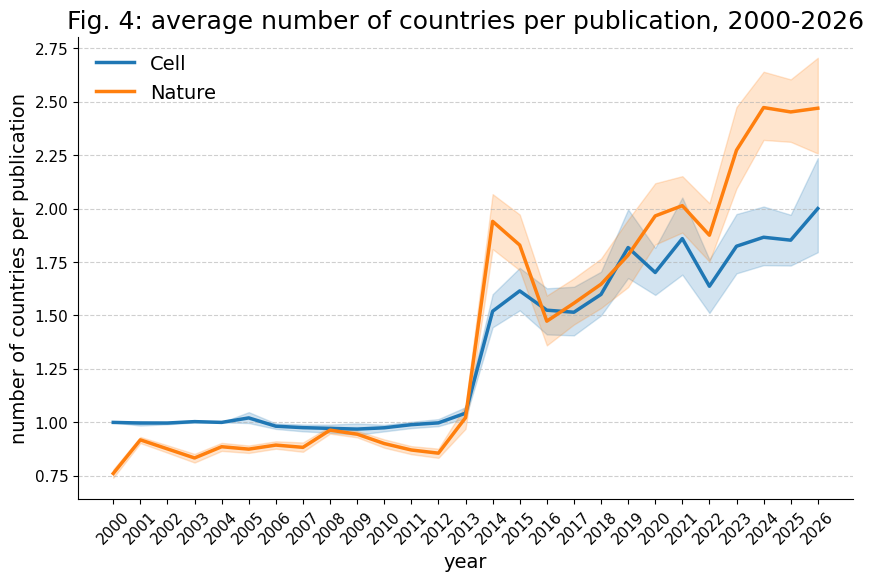


        ### Figure 4 takeaways: number of countries involved in each publication also tends to increase over time
        ### Note: pre-2014 authorship affiliation (and therefore country) was not consistently recorded. 
        ### Subsequent analyses done with data post-2014.
        

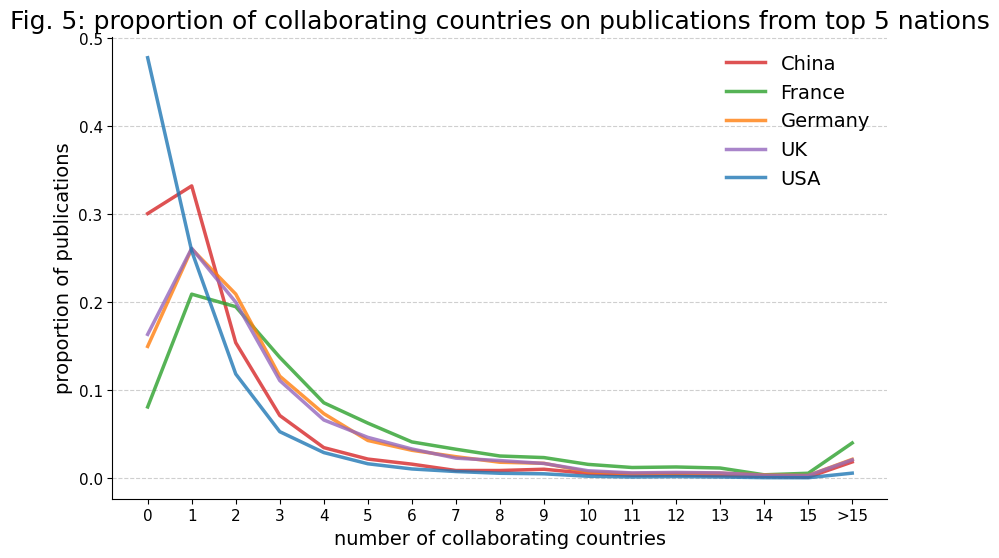


        ### Figure 5 takeaways: USA and China have the highest proportion of publications with authors from only that country. 
        ### Other countries tend to have less solo-country publications. Solo-country publications are generally a minority.    
        

In [5]:
# -----------------------------------------------
# display Pubmed author data exploratory analyses
# -----------------------------------------------

import pubmed_graphs
pubmed_graphs.run()